# Recommender Evaluation EDA

This notebook visualizes federated recommender evaluation artifacts across clients.

It focuses on:
- aggregate recommender metrics
- per-client variation
- highest and lowest scoring clients
- standard deviation and spread across clients
- relationships between evaluation scores and client data-distribution features
- training dynamics across rounds

In [7]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root containing pyproject.toml")


REPO_ROOT = find_repo_root()
REPO_ROOT

PosixPath('/gpfs/helios/home/kelemnegasi/fed-xai/fed-perso-xai')

In [8]:
# Edit these if you want to inspect another recommender evaluation run.
RUN_ID = "federated-training-adult_income-20260425t192946577949+0000-logistic_regression-10clients-alpha1.0-seed42-dba03a50b07b"
SELECTION_ID = "test__max-20__seed-42"
PERSONA = "lay"
RECOMMENDER_MODEL_KEY = "pairwise_logistic_fedavg"

TRAIN_DIR = (
    REPO_ROOT
    / "federated"
    / "runs"
    / RUN_ID
    / "recommender_training"
    / SELECTION_ID
    / PERSONA
    / RECOMMENDER_MODEL_KEY
)

EVALUATION_SUMMARY_PATH = TRAIN_DIR / "evaluation_summary.json"
TRAINING_METADATA_PATH = TRAIN_DIR / "training_metadata.json"
TRAINING_HISTORY_PATH = TRAIN_DIR / "training_history.csv"
FEATURE_METADATA_PATH = TRAIN_DIR / "feature_metadata.json"

for path in [EVALUATION_SUMMARY_PATH, TRAINING_METADATA_PATH, TRAINING_HISTORY_PATH, FEATURE_METADATA_PATH]:
    if not path.exists():
        raise FileNotFoundError(path)

TRAIN_DIR

PosixPath('/gpfs/helios/home/kelemnegasi/fed-xai/fed-perso-xai/federated/runs/federated-training-adult_income-20260425t192946577949+0000-logistic_regression-10clients-alpha1.0-seed42-dba03a50b07b/recommender_training/test__max-20__seed-42/lay/pairwise_logistic_fedavg')

In [9]:
def load_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))


def resolve_repo_path(path_text: str) -> Path:
    path = Path(path_text)
    return path if path.is_absolute() else REPO_ROOT / path


def expand_json_columns(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    result = frame.copy()
    for column in columns:
        if column not in result.columns:
            continue
        parsed = result[column].fillna("{}").map(json.loads)
        normalized = pd.json_normalize(parsed)
        normalized.columns = [f"{column}.{name}" for name in normalized.columns]
        result = pd.concat([result.drop(columns=[column]), normalized], axis=1)
    return result


RAW_CLIENT_DISTRIBUTION_COLUMNS = [
    "dataset_client_train_size",
    "dataset_client_test_size",
    "dataset_client_total_size",
    "dataset_client_class_entropy",
    "dataset_client_train_positive_rate",
    "dataset_client_test_positive_rate",
    "dataset_client_feature_mean_abs_mean",
    "dataset_client_feature_mean_std",
    "dataset_client_feature_std_mean",
    "dataset_client_feature_std_std",
    "dataset_client_feature_std_max",
    "dataset_client_feature_sparsity",
    "dataset_client_mean_abs_correlation",
]


def load_client_context_profile(context_path: Path) -> dict[str, float]:
    context = pd.read_parquet(context_path)
    if context.empty:
        return {}
    row = context.iloc[0]
    profile = {column: float(row[column]) for column in RAW_CLIENT_DISTRIBUTION_COLUMNS if column in row.index}
    profile["context_rows"] = int(len(context))
    profile["context_instances"] = int(context["dataset_index"].nunique()) if "dataset_index" in context.columns else 0
    profile["context_variants"] = int(context["method_variant"].nunique()) if "method_variant" in context.columns else 0
    return profile


evaluation_summary = load_json(EVALUATION_SUMMARY_PATH)
training_metadata = load_json(TRAINING_METADATA_PATH)
feature_metadata = load_json(FEATURE_METADATA_PATH)
training_history = pd.read_csv(TRAINING_HISTORY_PATH)
training_history = expand_json_columns(training_history, ["aggregation", "fit_metrics", "evaluate_metrics"])

evaluation_summary.keys()

dict_keys(['status', 'run_id', 'selection_id', 'persona', 'model_path', 'feature_count', 'client_count', 'generated_at', 'aggregate', 'clients'])

In [10]:
run_overview = pd.DataFrame(
    {
        "run_id": [evaluation_summary["run_id"]],
        "selection_id": [evaluation_summary["selection_id"]],
        "persona": [evaluation_summary["persona"]],
        "client_count": [evaluation_summary["client_count"]],
        "feature_count": [evaluation_summary["feature_count"]],
        "pair_count": [training_metadata["raw_pair_count"]],
        "augmented_pair_count": [training_metadata["pair_count"]],
        "candidate_count": [training_metadata["candidate_count"]],
        "instance_count": [training_metadata["instance_count"]],
        "rounds_completed": [training_metadata["rounds_completed"]],
        "simulation_backend": [training_metadata["simulation_backend_actual"]],
    }
)

run_overview

,run_id,selection_id,persona,client_count,feature_count,pair_count,augmented_pair_count,candidate_count,instance_count,rounds_completed,simulation_backend
0,federated-training-adult_income-20260425t19294...,test__max-20__seed-42,lay,10,128,235796,471592,9691,200,10,ray


In [11]:
client_metrics = pd.DataFrame(evaluation_summary["clients"])
client_artifacts = pd.DataFrame(training_metadata["clients"])

client_profiles = []
for row in training_metadata["clients"]:
    profile = {"client_id": row["client_id"]}
    profile.update(load_client_context_profile(resolve_repo_path(row["context_path"])))
    client_profiles.append(profile)

client_profiles = pd.DataFrame(client_profiles)

client_df = (
    client_metrics
    .merge(client_artifacts, on="client_id", how="left", suffixes=("", "_artifact"))
    .merge(client_profiles, on="client_id", how="left")
)

metric_columns = [column for column in client_df.columns if column == "pearson" or column.startswith("precision_at_")]
client_df["average_metric_score"] = client_df[metric_columns].mean(axis=1)
client_df["pairs_per_candidate"] = client_df["pair_count"] / client_df["candidate_count"]
client_df["candidates_per_instance"] = client_df["candidate_count"] / client_df["instance_count"]

client_df.sort_values("client_id").head()

,client_id,candidate_count,pair_count,variant_count,pearson,precision_at_1,precision_at_3,precision_at_5,candidate_count_artifact,instance_count,raw_pair_count,augmented_pair_count,context_path,labels_path,dataset_client_train_size,dataset_client_test_size,dataset_client_total_size,dataset_client_class_entropy,dataset_client_train_positive_rate,dataset_client_test_positive_rate,dataset_client_feature_mean_abs_mean,dataset_client_feature_mean_std,dataset_client_feature_std_mean,dataset_client_feature_std_std,dataset_client_feature_std_max,dataset_client_feature_sparsity,dataset_client_mean_abs_correlation,context_rows,context_instances,context_variants,average_metric_score,pairs_per_candidate,candidates_per_instance
0,client_000,1057,28051,63,0.951613,1.0,1.000000,0.8,1057,20,28051,56102,federated/runs/federated-training-adult_income...,federated/runs/federated-training-adult_income...,1886.0,472.0,2358.0,0.995603,0.460764,0.461864,0.081325,0.173793,0.202566,0.253438,1.388624,0.866667,0.032772,1057,20,63,0.937903,26.538316,52.85
1,client_001,936,21916,63,0.857815,0.0,0.333333,0.4,936,20,21916,43832,federated/runs/federated-training-adult_income...,federated/runs/federated-training-adult_income...,6793.0,1699.0,8492.0,0.680962,0.180333,0.180695,0.077652,0.169175,0.203115,0.235801,1.018863,0.866667,0.024854,936,20,63,0.397787,23.414530,46.80
2,client_002,895,20002,63,0.967838,0.0,0.333333,0.4,895,20,20002,40004,federated/runs/federated-training-adult_income...,federated/runs/federated-training-adult_income...,1470.0,368.0,1838.0,0.315934,0.057143,0.057065,0.080543,0.170952,0.198317,0.225026,1.011862,0.866667,0.031365,895,20,63,0.425293,22.348603,44.75
3,client_003,937,21802,63,0.859303,0.0,0.666667,0.8,937,20,21802,43604,federated/runs/federated-training-adult_income...,federated/runs/federated-training-adult_income...,5248.0,1312.0,6560.0,0.237801,0.039062,0.038872,0.081379,0.171642,0.196455,0.223512,1.026223,0.866667,0.025249,937,20,63,0.581492,23.267876,46.85
4,client_004,1039,26816,63,0.949453,1.0,0.333333,0.6,1039,20,26816,53632,federated/runs/federated-training-adult_income...,federated/runs/federated-training-adult_income...,1679.0,420.0,2099.0,0.981102,0.580703,0.580952,0.084674,0.178740,0.202103,0.261251,1.511619,0.866667,0.032250,1039,20,63,0.720697,25.809432,51.95


## Aggregate metrics and spread

`weighted_aggregate` is the value written by the evaluation pipeline.
`client_mean` and `client_std` are computed directly across clients in this notebook.

In [12]:
metric_summary = pd.DataFrame(index=metric_columns)
metric_summary["weighted_aggregate"] = pd.Series(evaluation_summary["aggregate"])
metric_summary["client_mean"] = client_df[metric_columns].mean()
metric_summary["client_std"] = client_df[metric_columns].std(ddof=1)
metric_summary["client_min"] = client_df[metric_columns].min()
metric_summary["client_max"] = client_df[metric_columns].max()
metric_summary = metric_summary.sort_index()

display(metric_summary.round(4))

,weighted_aggregate,client_mean,client_std,client_min,client_max
pearson,0.9111,0.9084,0.0443,0.8403,0.9678
precision_at_1,0.4526,0.4000,0.5164,0.0000,1.0000
precision_at_3,0.6770,0.6667,0.2722,0.3333,1.0000
precision_at_5,0.7085,0.7000,0.1944,0.4000,1.0000


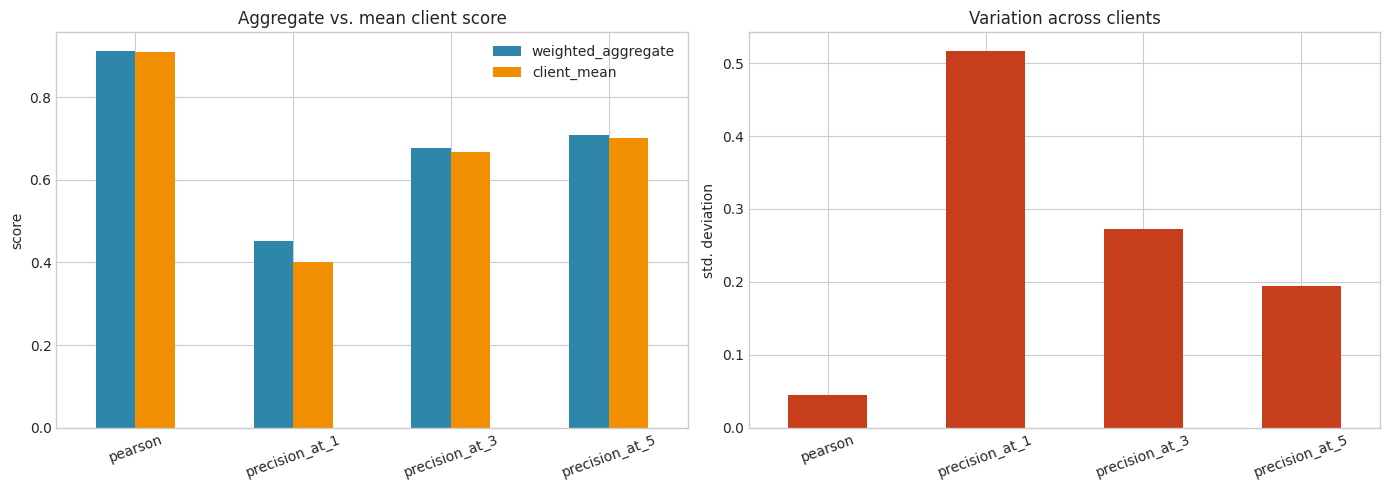

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metric_summary[["weighted_aggregate", "client_mean"]].plot(
    kind="bar",
    ax=axes[0],
    color=["#2E86AB", "#F18F01"],
)
axes[0].set_title("Aggregate vs. mean client score")
axes[0].set_ylabel("score")
axes[0].tick_params(axis="x", rotation=20)

metric_summary["client_std"].plot(
    kind="bar",
    ax=axes[1],
    color="#C73E1D",
)
axes[1].set_title("Variation across clients")
axes[1].set_ylabel("std. deviation")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## Per-client metric bar plots

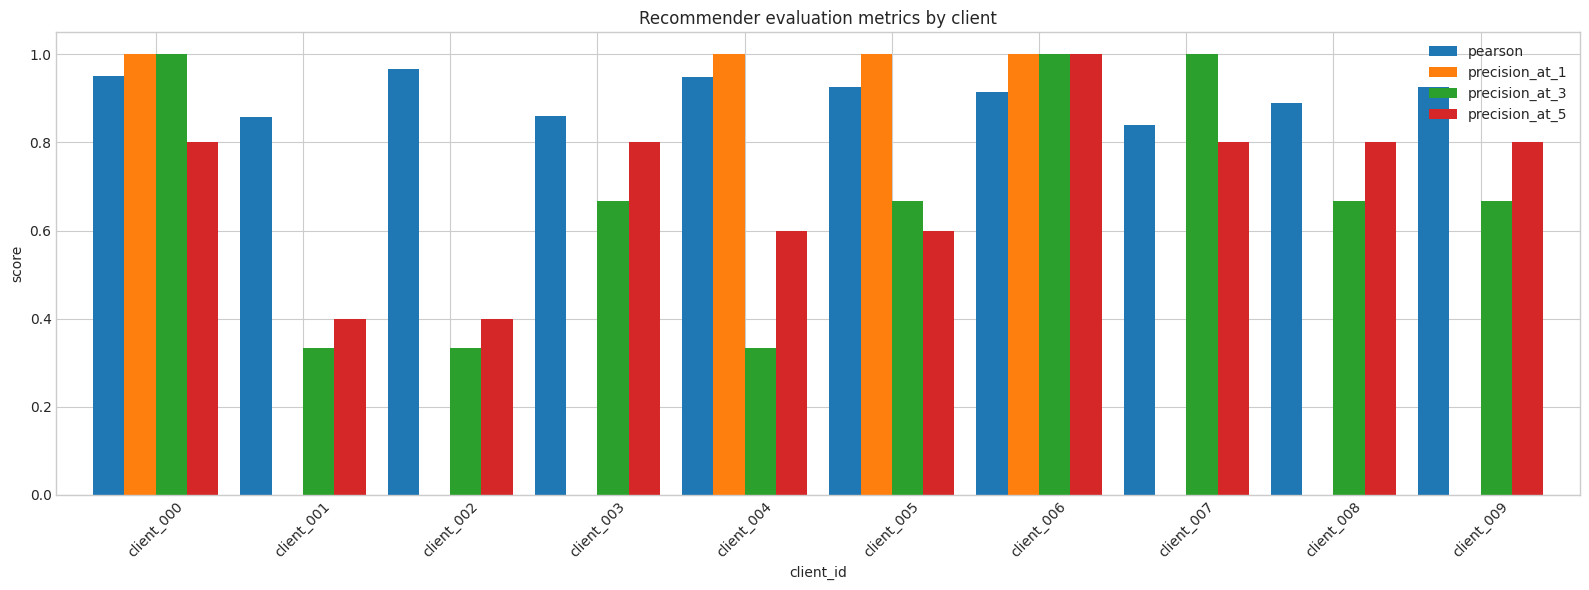

In [14]:
plot_frame = client_df.set_index("client_id")[metric_columns]
ax = plot_frame.plot(kind="bar", figsize=(16, 6), width=0.85)
ax.set_title("Recommender evaluation metrics by client")
ax.set_ylabel("score")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

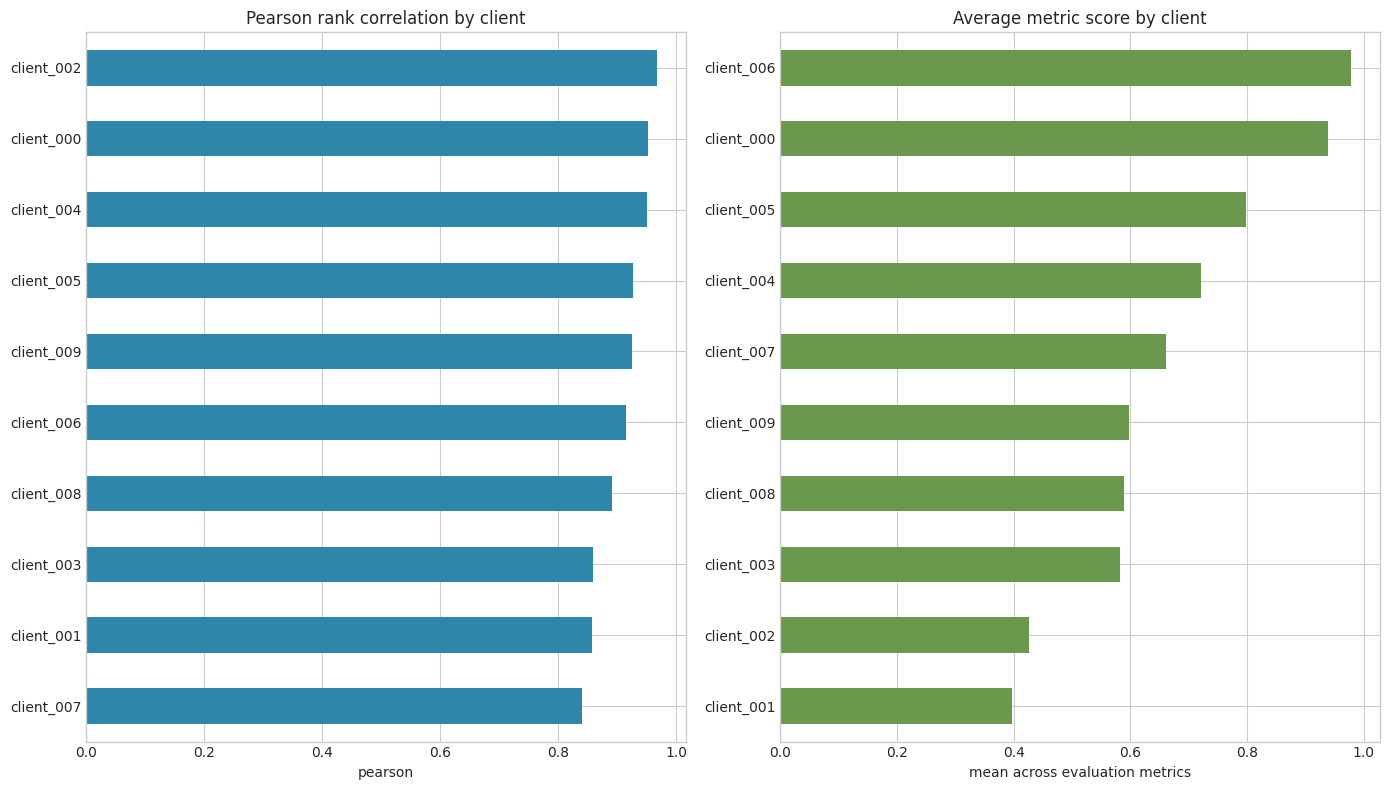

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

client_df.sort_values("pearson").plot(
    x="client_id",
    y="pearson",
    kind="barh",
    ax=axes[0],
    color="#2E86AB",
    legend=False,
)
axes[0].set_title("Pearson rank correlation by client")
axes[0].set_xlabel("pearson")
axes[0].set_ylabel("")

client_df.sort_values("average_metric_score").plot(
    x="client_id",
    y="average_metric_score",
    kind="barh",
    ax=axes[1],
    color="#6A994E",
    legend=False,
)
axes[1].set_title("Average metric score by client")
axes[1].set_xlabel("mean across evaluation metrics")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## Highest and lowest scoring clients

In [16]:
best_worst_rows = []
for metric in [*metric_columns, "average_metric_score"]:
    best = client_df.loc[client_df[metric].idxmax()]
    worst = client_df.loc[client_df[metric].idxmin()]
    best_worst_rows.append(
        {
            "metric": metric,
            "best_client": best["client_id"],
            "best_score": best[metric],
            "worst_client": worst["client_id"],
            "worst_score": worst[metric],
            "spread": best[metric] - worst[metric],
        }
    )

best_worst = pd.DataFrame(best_worst_rows)
display(best_worst.round({"best_score": 4, "worst_score": 4, "spread": 4}))

,metric,best_client,best_score,worst_client,worst_score,spread
0,pearson,client_002,0.9678,client_007,0.8403,0.1275
1,precision_at_1,client_000,1.0000,client_001,0.0000,1.0000
2,precision_at_3,client_000,1.0000,client_001,0.3333,0.6667
3,precision_at_5,client_006,1.0000,client_001,0.4000,0.6000
4,average_metric_score,client_006,0.9788,client_001,0.3978,0.5810


In [17]:
top_clients = client_df.sort_values("average_metric_score", ascending=False)[[
    "client_id",
    "average_metric_score",
    "pearson",
    "precision_at_1",
    "precision_at_3",
    "precision_at_5",
    "pair_count",
    "candidate_count",
    "dataset_client_class_entropy",
    "dataset_client_train_positive_rate",
    "dataset_client_feature_sparsity",
]]

display(top_clients.round({
    "average_metric_score": 4,
    "pearson": 4,
    "precision_at_1": 4,
    "precision_at_3": 4,
    "precision_at_5": 4,
    "dataset_client_class_entropy": 4,
    "dataset_client_train_positive_rate": 4,
    "dataset_client_feature_sparsity": 4,
}))

,client_id,average_metric_score,pearson,precision_at_1,precision_at_3,precision_at_5,pair_count,candidate_count,dataset_client_class_entropy,dataset_client_train_positive_rate,dataset_client_feature_sparsity
6,client_006,0.9788,0.9152,1.0,1.0000,1.0,27292,1045,1.0000,0.4979,0.8667
0,client_000,0.9379,0.9516,1.0,1.0000,0.8,28051,1057,0.9956,0.4608,0.8667
5,client_005,0.7984,0.9268,1.0,0.6667,0.6,24565,987,0.6860,0.1827,0.8667
4,client_004,0.7207,0.9495,1.0,0.3333,0.6,26816,1039,0.9811,0.5807,0.8667
7,client_007,0.6601,0.8403,0.0,1.0000,0.8,20666,909,0.3222,0.0584,0.8667
9,client_009,0.5980,0.9254,0.0,0.6667,0.8,25299,1006,0.9813,0.4198,0.8667
8,client_008,0.5892,0.8902,0.0,0.6667,0.8,19387,880,0.4890,0.1063,0.8667
3,client_003,0.5815,0.8593,0.0,0.6667,0.8,21802,937,0.2378,0.0391,0.8667
2,client_002,0.4253,0.9678,0.0,0.3333,0.4,20002,895,0.3159,0.0571,0.8667
1,client_001,0.3978,0.8578,0.0,0.3333,0.4,21916,936,0.6810,0.1803,0.8667


## Relationships to client data distribution

These plots use dataset-distribution descriptors embedded in the client recommender context.

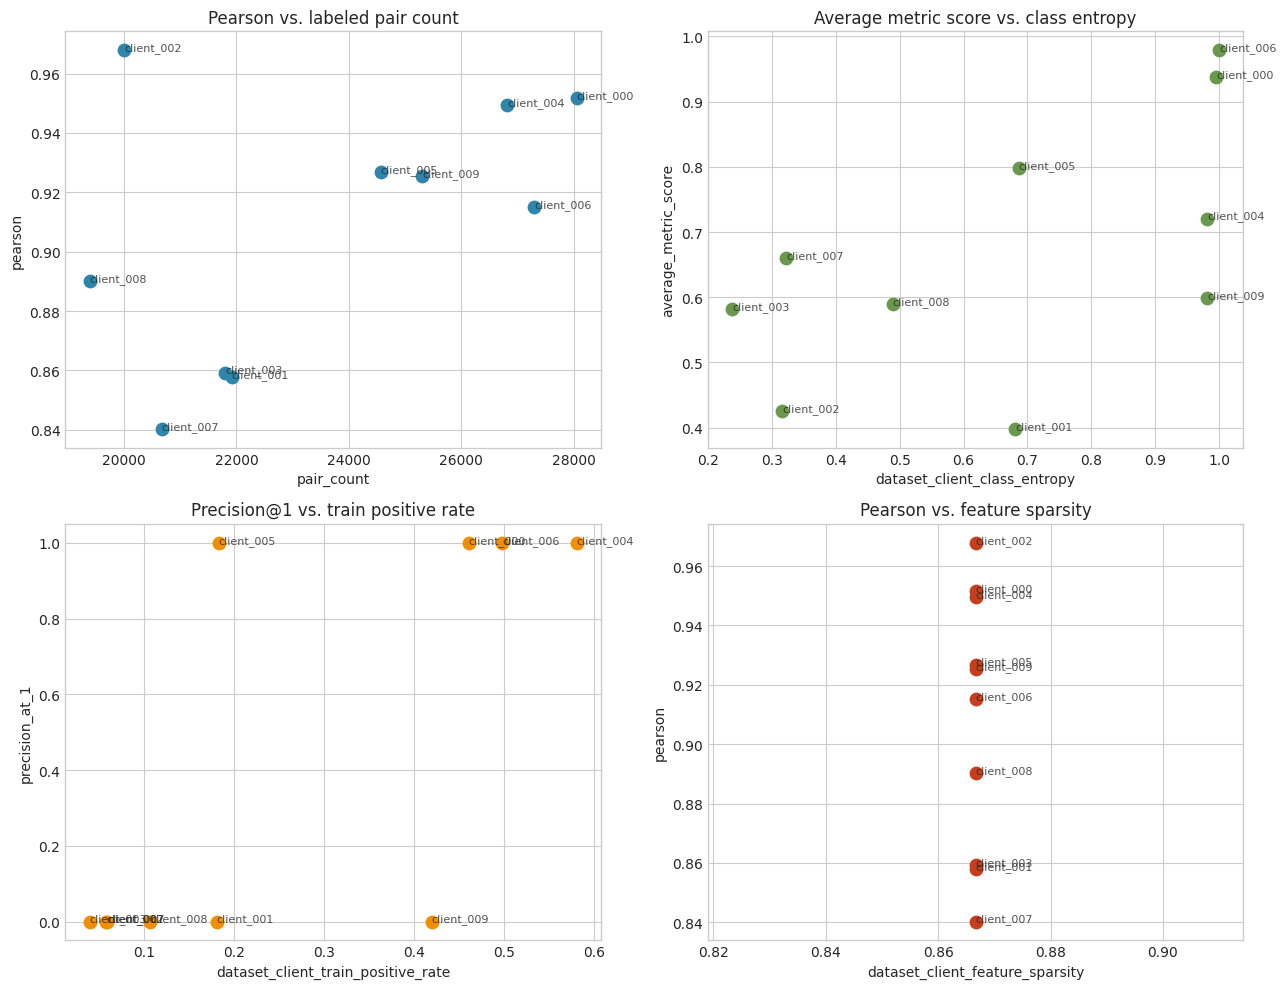

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

client_df.plot.scatter(
    x="pair_count",
    y="pearson",
    s=80,
    ax=axes[0, 0],
    color="#2E86AB",
)
axes[0, 0].set_title("Pearson vs. labeled pair count")

client_df.plot.scatter(
    x="dataset_client_class_entropy",
    y="average_metric_score",
    s=80,
    ax=axes[0, 1],
    color="#6A994E",
)
axes[0, 1].set_title("Average metric score vs. class entropy")

client_df.plot.scatter(
    x="dataset_client_train_positive_rate",
    y="precision_at_1",
    s=80,
    ax=axes[1, 0],
    color="#F18F01",
)
axes[1, 0].set_title("Precision@1 vs. train positive rate")

client_df.plot.scatter(
    x="dataset_client_feature_sparsity",
    y="pearson",
    s=80,
    ax=axes[1, 1],
    color="#C73E1D",
)
axes[1, 1].set_title("Pearson vs. feature sparsity")

for _, row in client_df.iterrows():
    axes[0, 0].annotate(row["client_id"], (row["pair_count"], row["pearson"]), fontsize=8, alpha=0.8)
    axes[0, 1].annotate(row["client_id"], (row["dataset_client_class_entropy"], row["average_metric_score"]), fontsize=8, alpha=0.8)
    axes[1, 0].annotate(row["client_id"], (row["dataset_client_train_positive_rate"], row["precision_at_1"]), fontsize=8, alpha=0.8)
    axes[1, 1].annotate(row["client_id"], (row["dataset_client_feature_sparsity"], row["pearson"]), fontsize=8, alpha=0.8)

plt.tight_layout()
plt.show()

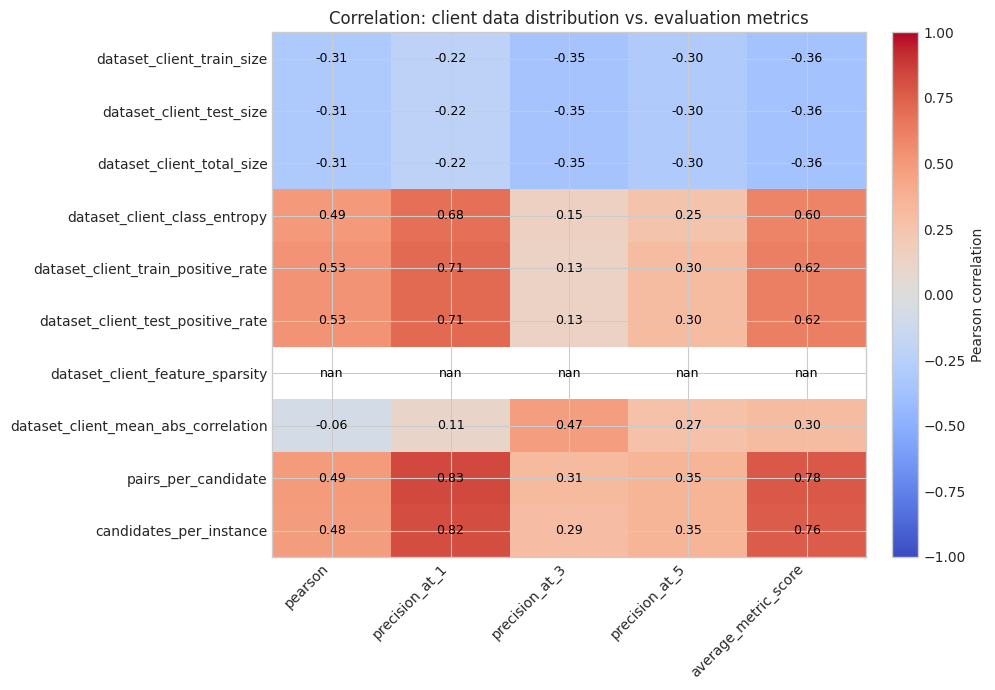

In [19]:
correlation_features = [
    "dataset_client_train_size",
    "dataset_client_test_size",
    "dataset_client_total_size",
    "dataset_client_class_entropy",
    "dataset_client_train_positive_rate",
    "dataset_client_test_positive_rate",
    "dataset_client_feature_sparsity",
    "dataset_client_mean_abs_correlation",
    "pairs_per_candidate",
    "candidates_per_instance",
]

corr = client_df[correlation_features + metric_columns + ["average_metric_score"]].corr(numeric_only=True)
heatmap = corr.loc[correlation_features, metric_columns + ["average_metric_score"]]

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(heatmap.to_numpy(), cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
ax.set_xticks(range(len(heatmap.columns)), heatmap.columns, rotation=45, ha="right")
ax.set_yticks(range(len(heatmap.index)), heatmap.index)
ax.set_title("Correlation: client data distribution vs. evaluation metrics")

for i in range(heatmap.shape[0]):
    for j in range(heatmap.shape[1]):
        value = heatmap.iat[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="black", fontsize=9)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Pearson correlation")
plt.tight_layout()
plt.show()

## Training dynamics across rounds

,evaluate_loss,round,aggregation.helper_count,aggregation.mode,aggregation.num_contributors,fit_metrics.num_examples,fit_metrics.shared_parameter_count,fit_metrics.train_loss,evaluate_metrics.num_examples,evaluate_metrics.pairwise_accuracy
0,0.652685,1,0,plain,10,471592.0,2.0,0.291162,471592.0,0.846024
1,0.592082,2,0,plain,10,471592.0,2.0,0.278633,471592.0,0.847069
2,0.664584,3,0,plain,10,471592.0,2.0,0.338067,471592.0,0.847309
3,0.690570,4,0,plain,10,471592.0,2.0,0.353521,471592.0,0.847595
4,0.694084,5,0,plain,10,471592.0,2.0,0.344814,471592.0,0.847523


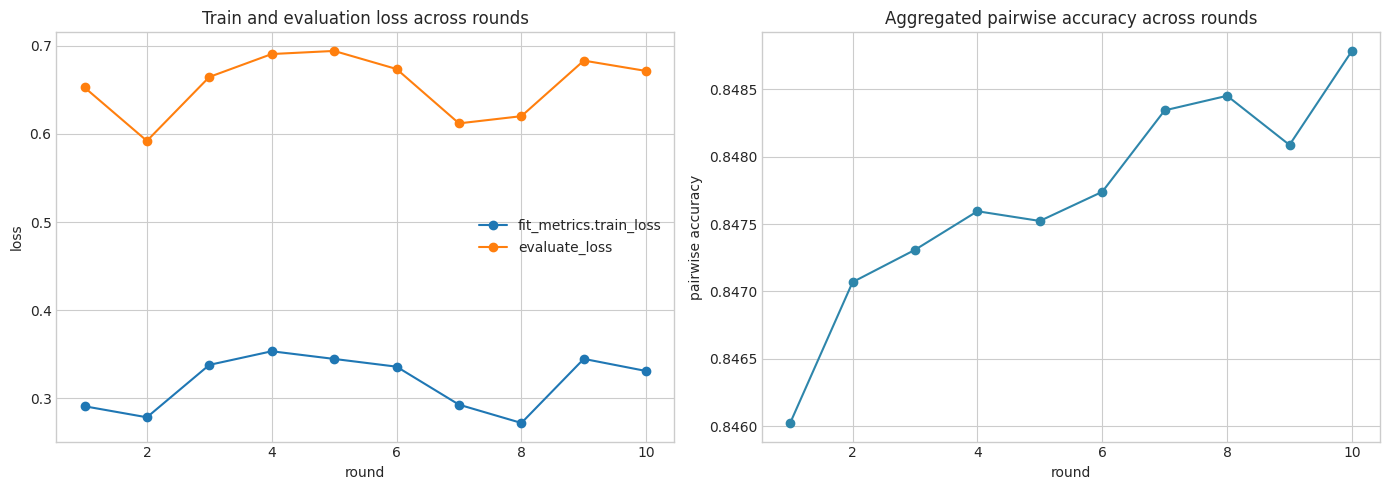

In [20]:
display(training_history.head())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

training_history.plot(
    x="round",
    y=["fit_metrics.train_loss", "evaluate_loss"],
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Train and evaluation loss across rounds")
axes[0].set_ylabel("loss")

training_history.plot(
    x="round",
    y="evaluate_metrics.pairwise_accuracy",
    marker="o",
    ax=axes[1],
    color="#2E86AB",
    legend=False,
)
axes[1].set_title("Aggregated pairwise accuracy across rounds")
axes[1].set_ylabel("pairwise accuracy")

plt.tight_layout()
plt.show()

## Metric distributions across clients

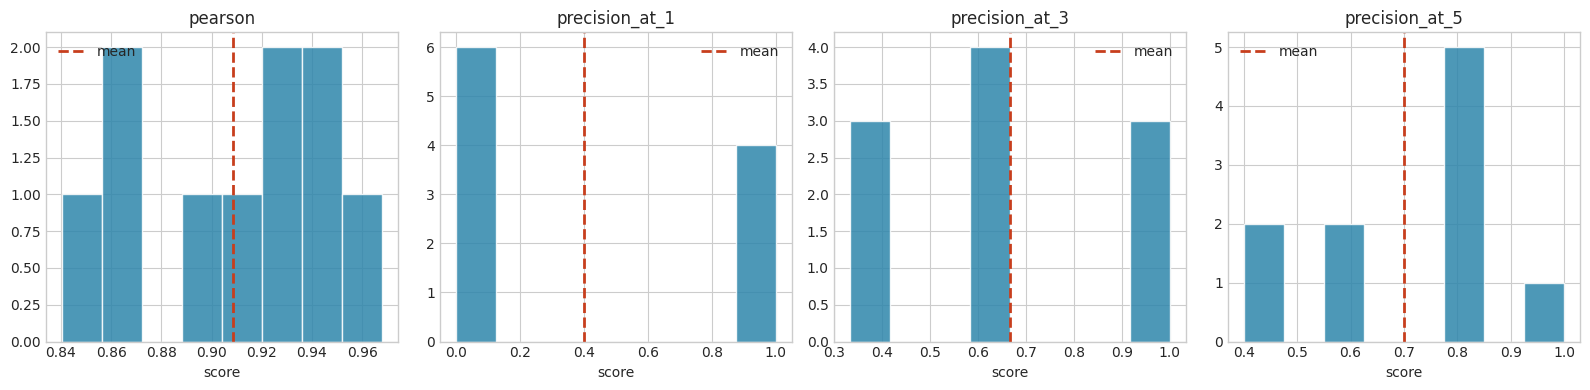

In [21]:
fig, axes = plt.subplots(1, len(metric_columns), figsize=(4 * len(metric_columns), 4), sharey=False)
if len(metric_columns) == 1:
    axes = [axes]

for ax, metric in zip(axes, metric_columns):
    ax.hist(client_df[metric], bins=min(8, len(client_df)), color="#2E86AB", alpha=0.85, edgecolor="white")
    ax.axvline(client_df[metric].mean(), color="#C73E1D", linestyle="--", linewidth=2, label="mean")
    ax.set_title(metric)
    ax.set_xlabel("score")
    ax.legend()

plt.tight_layout()
plt.show()

## Quick summary

This final table is a compact client report with performance plus data-distribution context.

In [22]:
summary_columns = [
    "client_id",
    "average_metric_score",
    "pearson",
    "precision_at_1",
    "precision_at_3",
    "precision_at_5",
    "pair_count",
    "candidate_count",
    "candidates_per_instance",
    "dataset_client_total_size",
    "dataset_client_class_entropy",
    "dataset_client_train_positive_rate",
    "dataset_client_feature_sparsity",
]

display(client_df[summary_columns].sort_values("average_metric_score", ascending=False).round({
    "average_metric_score": 4,
    "pearson": 4,
    "precision_at_1": 4,
    "precision_at_3": 4,
    "precision_at_5": 4,
    "candidates_per_instance": 2,
    "dataset_client_class_entropy": 4,
    "dataset_client_train_positive_rate": 4,
    "dataset_client_feature_sparsity": 4,
}))

,client_id,average_metric_score,pearson,precision_at_1,precision_at_3,precision_at_5,pair_count,candidate_count,candidates_per_instance,dataset_client_total_size,dataset_client_class_entropy,dataset_client_train_positive_rate,dataset_client_feature_sparsity
6,client_006,0.9788,0.9152,1.0,1.0000,1.0,27292,1045,52.25,2436.0,1.0000,0.4979,0.8667
0,client_000,0.9379,0.9516,1.0,1.0000,0.8,28051,1057,52.85,2358.0,0.9956,0.4608,0.8667
5,client_005,0.7984,0.9268,1.0,0.6667,0.6,24565,987,49.35,6102.0,0.6860,0.1827,0.8667
4,client_004,0.7207,0.9495,1.0,0.3333,0.6,26816,1039,51.95,2099.0,0.9811,0.5807,0.8667
7,client_007,0.6601,0.8403,0.0,1.0000,0.8,20666,909,45.45,835.0,0.3222,0.0584,0.8667
9,client_009,0.5980,0.9254,0.0,0.6667,0.8,25299,1006,50.30,6013.0,0.9813,0.4198,0.8667
8,client_008,0.5892,0.8902,0.0,0.6667,0.8,19387,880,44.00,2340.0,0.4890,0.1063,0.8667
3,client_003,0.5815,0.8593,0.0,0.6667,0.8,21802,937,46.85,6560.0,0.2378,0.0391,0.8667
2,client_002,0.4253,0.9678,0.0,0.3333,0.4,20002,895,44.75,1838.0,0.3159,0.0571,0.8667
1,client_001,0.3978,0.8578,0.0,0.3333,0.4,21916,936,46.80,8492.0,0.6810,0.1803,0.8667
